# Problem set 7

## Name: Qiuli Lai

## Link to your PS7 github repo: https://github.com/kyulli/data1030-fall2025.git

### Problem 0 

-2 points for every missing green OK sign. 

Make sure you are in the DATA1030 environment.

In [1]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.10"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.10"):
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "2.2.5", 'matplotlib': "3.10.1",'sklearn': "1.6.1", 
                'pandas': "2.2.3",'xgboost': "3.0.0", 'shap': "0.47.2", 
                'polars': "1.27.1", 'seaborn': "0.13.2"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.13.5

[ OK ] numpy version 2.2.5 is installed.
[ OK ] matplotlib version 3.10.1 is installed.
[ OK ] sklearn version 1.6.1 is installed.
[ OK ] pandas version 2.2.3 is installed.
[ OK ] xgboost version 3.0.0 is installed.
[ OK ] shap version 0.47.2 is installed.
[ OK ] polars version 1.27.1 is installed.
[ OK ] seaborn version 0.13.2 is installed.


### Problem 1a (10 points)

Please load the true_labels_pred_probs.csv file from the data folder into a data frame. It contains the true labels and the predicted probabilities of class 0 and 1 in a classification problem. Class 0 indicates a patient does not have a disease, while Class 1 indicates that a patient does have the disease.

Please prepare the predicted classes for a critical probability of 25%, 50%, and 75% and create three confusion matrix plots. Put the critical probability value in the title of each graph. In a paragraph, explain how the model's performance is impacted by the critical probability with respect to the confusion matrices. Given the model's specified deployment task, what are the implications of choosing one of the critical probabilities over the other?

   y_true  pred_prob_class0  pred_prob_class1
0       0          0.705171          0.294829
1       0          0.811506          0.188494
2       1          0.123507          0.876493
3       0          0.932019          0.067981
4       0          0.884029          0.115971


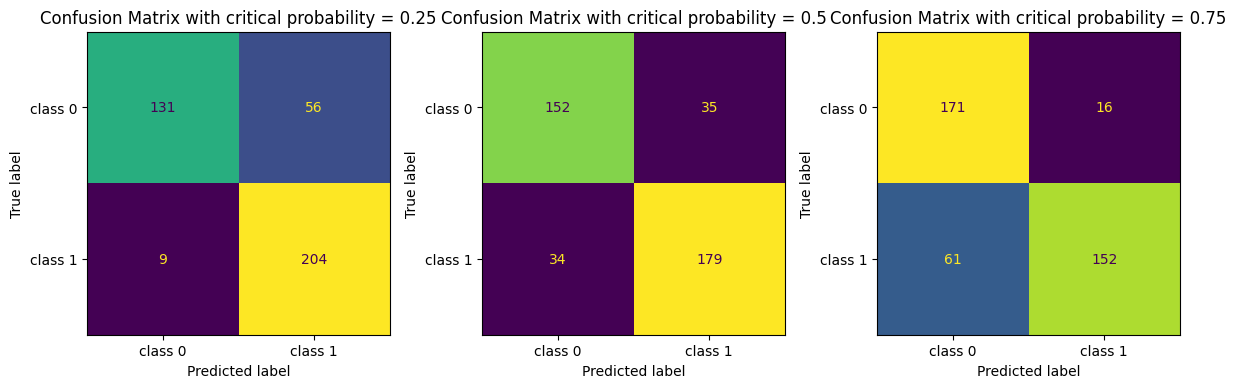

In [9]:
# your code here
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
import numpy as np

df = pd.read_csv('data/true_labels_pred_probs.csv')
print(df.head())
p_crits = [0.25, 0.5, 0.75]
y_true = df['y_true']
pred_prob_class0, pred_prob_class1 = df['pred_prob_class0'], df['pred_prob_class1']

fpr = np.zeros(len(y_true))
tpr = np.zeros(len(y_true))

fig,axes =plt.subplots(1,3, figsize = (12,4))

for i in range(len(p_crits)):
    p_crit = p_crits[i]
    y_pred = (pred_prob_class1 >= p_crit).astype(int)

    C = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=C, display_labels=['class 0', 'class 1'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f'Confusion Matrix with critical probability = {p_crit}')

plt.tight_layout()
plt.show()


**your explanation here**

As the critical probability increases from 0.25 to 0.5 to 0.75, we found out that the classifier becomes progressively less accurate on predcting class 1, at p_crit = 0.25, only 9 FN, which is good, however it is at the cost of substantilly more FP(56). Raising the p_crit, the FN increases, FP decreases, finally reached a minimize 16 on FP, which is good, however the model misses 61 diseased patients,. In a medical diagnosis setting where the cost of the FP, lower thresholds afer generally preferred becasue they prioritize sensitivity over speficity. Choosing a higher threshold reduces unnecessary alarms but increases the risk of overlooking patients who actually have the disease. Therefore, the appropriate threshold depends on how much risk the deployment context is willing to accept, but for high-stakes clinical screening, the lower critical probability is typically the safer choice.

### Problem 1b (9 points)

Calculate and plot the accuracy, precision, recall, f0.5, f1, and f1.5 scores using the sorted values of the Class 1 predicted probabilities.

What critical probability maximizes each of the scores (one critical probability per score)? That critical probability is what you should use to maximize the scores.

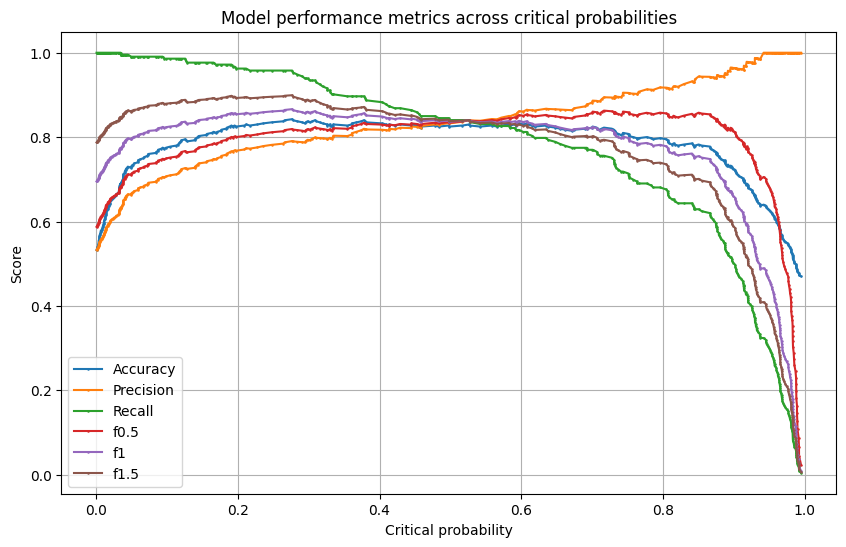

In [11]:
# your code here 
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score

p_crits = np.sort(pred_prob_class1)
accs = []
pres = []
recs = []
f0_5 = []
f1 = []
f1_5 = []

for i in range(len(p_crits)):
    p_crit = p_crits[i]
    y_pred = (pred_prob_class1 >= p_crit).astype(int)

    accs.append(accuracy_score(y_true, y_pred))
    pres.append(precision_score(y_true,y_pred))
    recs.append(recall_score(y_true, y_pred))
    f0_5.append(fbeta_score(y_true, y_pred, beta=0.5))
    f1.append(fbeta_score(y_true, y_pred, beta=1))
    f1_5.append(fbeta_score(y_true, y_pred, beta=1.5))

plt.figure(figsize=(10,6))
plt.plot(p_crits, accs, marker='o', markersize = 0.8, label='Accuracy')
plt.plot(p_crits, pres, marker='o', markersize = 0.8, label='Precision')
plt.plot(p_crits, recs, marker='o', markersize = 0.8, label='Recall')
plt.plot(p_crits, f0_5, marker='o', markersize = 0.8, label='f0.5')
plt.plot(p_crits, f1, marker='o', markersize = 0.8, label='f1')
plt.plot(p_crits, f1_5, marker='o', markersize = 0.8, label='f1.5')

plt.xlabel("Critical probability")
plt.ylabel("Score")
plt.title("Model performance metrics across critical probabilities")
plt.legend()
plt.grid(True)



In [4]:
print('The critical probability that maximizes the accuracy score =', p_crits[np.argmax(accs)])
print('The critical probability that maximizes the recall score =', p_crits[np.argmax(recs)])
print('The critical probability that maximizes the precision score =', p_crits[np.argmax(pres)])
print('The critical probability that maximizes the f0.5 score =', p_crits[np.argmax(f0_5)])
print('The critical probability that maximizes the f1 score =', p_crits[np.argmax(f1)])
print('The critical probability that maximizes the f1_5 score =', p_crits[np.argmax(f1_5)])

The critical probability that maximizes the accuracy score = 0.2663314471417387
The critical probability that maximizes the recall score = 0.0008787104301093
The critical probability that maximizes the precision score = 0.9371118324791012
The critical probability that maximizes the f0.5 score = 0.7130953411781936
The critical probability that maximizes the f1 score = 0.2663314471417387
The critical probability that maximizes the f1_5 score = 0.2663314471417387


Because medical screening places far higher cost on false negatives than on false positives, a comparatively lower critical probability (around 0.266 in this dataset) is preferable, since it increases sensitivity and reduces the chance of missing true disease cases.

### Problem 1c (3 points)

One of the curves you plotted is non-decreasing and another curve is non-increasing. Which evaluation metrics correspond to these two curves and why is this a problem when you try to tune the critical probability? Explain your answer in a few sentences.


**your explanation here**

From the figure, the non-increasing curve is the recall score curve, and the non-decreasing curve is the precision score curve.
the evaluation metrics correspond to the two curve is the Precision-Recall curve, it's about the tune because the recall decreases as the accuracy increases, the two metrics move in opposite directions, so improving precision necessarily reduces recall. As a result, no single critical probability can maximize both metrics simultaneously, and the choice of threshold must depend on the relative cost of false positives versus false negatives.

### Problem 2a (5 points)

Work with true_labels_pred_probs.csv again. 

Calculate the points on the ROC curve and plot it. 

Print out the best critical probability by finding the point on the ROC curve that's closest to the perfect classifier (0,1) point. 

Check out the wikipedia page of the [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Further_interpretations) to read more about other ways to determine the best critical probability, and other ways to summarize the ROC curve.

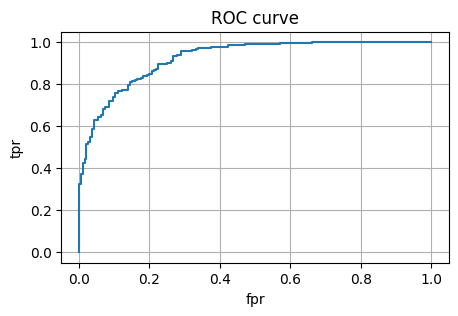

Best critical probability from ROC = 0.5967301685054103
FPR = 0.1497326203208556 TPR = 0.8169014084507042


In [12]:
# your code here 
from sklearn.metrics import roc_curve

fpr = np.zeros(len(y_true))
tpr = np.zeros(len(y_true))
p_crits = np.sort(pred_prob_class1)

for i in range(len(p_crits)):
    y_pred = (pred_prob_class1 >= p_crits).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tpr[i] = C[1,1] / (C[1,1] + C[1,0])
    fpr[i] = C[0,1] / (C[0,1] + C[0,0])

fpr, tpr, p_crits = roc_curve(y_true, pred_prob_class1)
plt.figure(figsize=(5,3))
plt.plot(fpr,tpr)
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.grid(True)
plt.show()

dist = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
best_idx = np.argmin(dist)

print("Best critical probability from ROC =", p_crits[best_idx])
print("FPR =", fpr[best_idx], "TPR =", tpr[best_idx])

### Problem 2b (10 points)

We discussed in class that the baseline accuracy of a classification model is equal to the fraction of points that belong to the most populous class. For example, if 80% of points belong to class 0 and 20% of points belong to class 1, we could predict class 0 for all points and the accuracy of our model would be 80%. In general, the baseline score is the best score you can achieve knowing no additional information about the features. You use information about your target variable only (in this case, only what percent of points are in each class). Keep this concept and methodology in mind and answer the questions below.

Q1: How do you calculate the baseline f1 score in classification? Let's assume $n_0$ points are in class 0 and $n_1 = n - n_0$ points are in class 1 where $n$ is the number of points in your dataset, and $n_0 > n_1$ so class 1 is the minority class. Work out the solution on pen and paper. Express the f1 score using $p$ (precision) and/or $r$ (recall).

**your explanation here**

baseline accuracy = accuracy of predicting the majority class for all samples
~ $\frac{max(n_0,n_1)}{n_0+n_1}$, since n0>n1, class 0 is the majority and class 1 is the minority.
so $y^{*} = 0$ for any points. We have

$$TP = n_0, TN = 0, FN = 0, FP = n_1$$

$$ P=\frac{TP}{TP+FP}=\frac{n_0}{n_0+n_1}=f.$$
$$R = \frac{TP}{TP+FN} = \frac{n_0}{n_0} = 1$$

$$f_1=\frac{2PR}{P+R}=\frac{2f}{1+f}.$$

Q2: Generalize your Q1 solution to the f_beta score. Usually the f_beta score is used when the classification problem is imbalanced. Prepare a figure which shows the baseline f_beta score for beta = 0.5, 1, and 2 when the fraction of points that belong to class 0 is between 0.95 and 1 in the target variable. Use 51 linearly spaced values between 0.95 and 1.
Create a plot with three curves, one curve per beta value. Don't forget to add axes labels, a title, and a legend.

R = TP/(TP+FN) = 1 

p = fractions/(fractions+(1-fractions)) = fractions

$$f_\beta \;=\; \frac{(1+\beta^2)\,PR}{\beta^2 P+R}
\;=\; \frac{(1+\beta^2)\,f}{\beta^2 f + 1}.$$

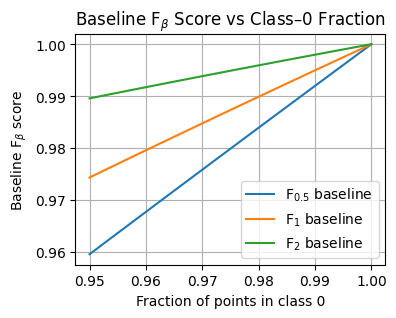

In [16]:
# your code here
fractions = np.linspace(0.95, 1, 51)

def f_beta(p, beta):
    return (1 + beta**2) * p / (beta**2 * p + 1)

f_beta_05 = f_beta(fractions, 0.5)
f_beta_1  = f_beta(fractions, 1)
f_beta_2  = f_beta(fractions, 2)

plt.figure(figsize=(4,3))
plt.plot(fractions, f_beta_05, label='F$_{0.5}$ baseline')
plt.plot(fractions, f_beta_1,  label='F$_1$ baseline')
plt.plot(fractions, f_beta_2,  label='F$_2$ baseline')

plt.xlabel('Fraction of points in class 0')
plt.ylabel('Baseline F$_\\beta$ score')
plt.title('Baseline F$_\\beta$ Score vs Class–0 Fraction')
plt.grid(True)
plt.legend()
plt.show()

### Problem 2c (10 points)

So far, we've discussed calculating f1 scores in binary classification problems. However, for multiclass problems, there are multiple ways to calculate an f1 score. Look up three different approaches and explain how to calculate them in a short description with equations. Create a simple toy dataset and calculate the f1 scores using sklearn. Discuss the pros and cons of each approach.

**your explanation here**
1. **Macro F1.** Compute F1 for each class independently, treating each class as “positive” and the rest as “negative,” kind of like the OVA, then average them:
    $$F_1^{\text{macro}} = \frac{1}{K} \sum_{k=1}^K F_{1,k}.$$
    
    Interpretation: All classes contribute equally, regardless of frequency.
    Strength: Highlights poor performance on minority classes.
    Weakness: Can be very low when model performs poorly on rare classes.

    Reference:
    • KDnuggets — “Micro, Macro & Weighted Averages of F1 Score”
https://www.kdnuggets.com/2023/01/micro-macro-weighted-averages-f1-score-clearly-explained.html

2. **Weighted F1**. Weight each class by its support (number of samples):
    $$F_1^{\text{weighted}} = \sum_{k=1}^K \frac{n_k}{n} F_{1,k}.$$

    Interpretation: Majority classes dominate the score.
    Strength: More stable when the dataset is imbalanced.
    Weakness: Can hide the fact that minority classes perform poorly.

    Reference:
        •	Scikit-Learn Documentation — f1_score
    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html


3.  **Micro F1.** Aggregate global true positives, false positives, and false negatives:
    
    $$p_{\text{micro}} =
    \frac{\sum_k TP_k}{\sum_k (TP_k + FP_k)}, \qquad
    r_{\text{micro}} =
    \frac{\sum_k TP_k}{\sum_k (TP_k + FN_k)},$$
   $$ F_1^{\text{micro}} =
    \frac{2p_{\text{micro}}r_{\text{micro}}}{p_{\text{micro}} + r_{\text{micro}}}.$$

Interpretation: Treats each individual prediction equally.
Strength: Good summary when all classes have similar priority.
Weakness: Completely insensitive to class imbalance; essentially reduces to accuracy in multiclass settings.

Reference:
    •	Amir Masoud — “Understanding Micro, Macro, and Weighted Averages for Scikit-Learn”
https://iamirmasoud.com/2022/06/19/understanding-micro-macro-and-weighted-averages-for-scikit-learn-metrics-in-multi-class-classification-with-example


In [7]:
# your code here
from sklearn.metrics import f1_score
import numpy as np

# toy true labels and predictions
y_true = np.array([0, 1, 2, 2, 1, 0, 2, 1])
y_pred = np.array([0, 1, 2, 0, 1, 0, 1, 1])

macro = f1_score(y_true, y_pred, average='macro')
weighted = f1_score(y_true, y_pred, average='weighted')
micro = f1_score(y_true, y_pred, average='micro')

macro, weighted, micro

(0.719047619047619, 0.7089285714285714, 0.75)

### Problem 3 (5 points)

The true and predicted target variables of a regression problem are available in the `data/reg.cvs`. The goal of the model is to predict people's ages so the target variable's unit is year. 

We discussed the R2 score in class:

$R^2(y,y') = 1 - \frac{\sum_{i=1}^{n}(y_i-y_i')^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$,
where $\bar{y}$ is the mean of $y$.

The baseline (or constant) regression model returns the mean of $y$ as prediction for all data points ($y_i' == \bar{y}$ for all $i$). So the baseline R2 score is 0.

Calculate and print the baseline R2, MSE, RMSE, and MAE, **assuming that $y_i' == \bar{y}$ for all $i$**. Make sure to include the units for each metric. 

Next, calculate and print the R2 score, MSE, RMSE, and MAE **using the model predictions** and add the units of the metrics.

### R2 score - coefficient of determination, regression metrics

$R^2(y,y') = 1 - \frac{\sum_{i=1}^{m}(y_i-y_i')^2}{\sum_{i=1}^{m}(y_i-\bar{y})^2}$,</center>
where $\bar{y}$ is the mean of $y$

- R2 = 1 is the perfect regression model ($y == y'$)
- R2 = 0 is as good as a constant model that always predicts the expected value of y ($\bar{y}$)
- R2 < 0 is a bad regression model

In [8]:
# your code here
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
data = pd.read_csv('data/reg.csv')
y_true = data['y_true']
y_pred = data['y_pred']

y_mean = np.array([y_true.mean()] * len(y_true))

r2_baseline = 0
mse_baseline = mean_squared_error(y_true,y_mean)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_true, y_mean)

print("Baseline R2:", r2_baseline)
print("Baseline MSE:", mse_baseline, "years^2")
print("Baseline RMSE:", rmse_baseline, "years")
print("Baseline MAE:", mae_baseline, "years")


r2_model = r2_score(y_true, y_pred)
mse_model = mean_squared_error(y_true, y_pred)
rmse_model = np.sqrt(mse_model)
mae_model = mean_absolute_error(y_true, y_pred)

print("\nModel R2:", r2_model)
print("Model MSE:", mse_model, "years^2")
print("Model RMSE:", rmse_model, "years")
print("Model MAE:", mae_model, "years")

Baseline R2: 0
Baseline MSE: 589.1229249402501 years^2
Baseline RMSE: 24.27185458386421 years
Baseline MAE: 21.34778621318614 years

Model R2: 0.8599431892772426
Model MSE: 82.51067799079387 years^2
Model RMSE: 9.083538847321227 years
Model MAE: 7.2111631295468 years
